In [109]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Synthetic high pulse-rate audio -> harmonics in spectrogram
# ---------------------------

def pulse_train(fs: int,
                duration_s: float,
                prr_hz: float,
                pulse_sigma_s: float = 20e-6,
                amp: float = 1.0,
                jitter_std_s: float = 0.0,
                seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """
    Create a pulse train: short Gaussian pulses repeated at PRR (pulse repetition rate).
    Optional timing jitter breaks periodicity (harmonics smear).
    """
    rng = np.random.default_rng(seed)
    n = int(fs * duration_s)
    t = np.arange(n) / fs
    x = np.zeros(n, dtype=np.float64)

    T = 1.0 / prr_hz
    # Pulse centers
    centers = np.arange(0, duration_s, T)
    if jitter_std_s > 0:
        centers = centers + rng.normal(0.0, jitter_std_s, size=centers.shape)
        centers = centers[(centers >= 0) & (centers < duration_s)]

    # Precompute a pulse kernel (Gaussian) for efficiency
    # Kernel spans ±4 sigma
    half_w = int(np.ceil(4 * pulse_sigma_s * fs))
    k_t = np.arange(-half_w, half_w + 1) / fs
    kernel = np.exp(-0.5 * (k_t / pulse_sigma_s) ** 2)
    kernel = amp * kernel / np.max(kernel)

    # Add pulses
    for c in centers:
        idx = int(round(c * fs))
        i0 = idx - half_w
        i1 = idx + half_w + 1
        if i0 < 0 or i1 > n:
            continue
        x[i0:i1] += kernel

    # Remove DC and normalize
    x -= np.mean(x)
    mx = np.max(np.abs(x)) + 1e-12
    x /= mx
    return t, x


def plot_spectrogram(x: np.ndarray,
                     fs: int,
                     title: str,
                     nfft: int = 4096,
                     noverlap: int = 3072,
                     fmax: float | None = None):
    """
    Plot magnitude spectrogram in dB using matplotlib (no seaborn).
    """
    plt.figure(figsize=(10, 5))
    Pxx, freqs, bins, im = plt.specgram(
        x,
        NFFT=nfft,
        Fs=fs,
        noverlap=noverlap,
        scale_by_freq=True,
        sides="default",
        mode="psd",
        cmap="magma"
    )
    # Convert to dB for visibility
    im.set_clim(-140, -40)  # adjust if needed

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    if fmax is not None:
        plt.ylim(0, fmax)
    plt.colorbar(im, label="Power (dB)")
    plt.tight_layout()


def plot_waveform(t: np.ndarray, x: np.ndarray, title: str, tmax: float = 0.01):
    plt.figure(figsize=(10, 3))
    m = t <= tmax
    plt.plot(t[m], x[m])
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()



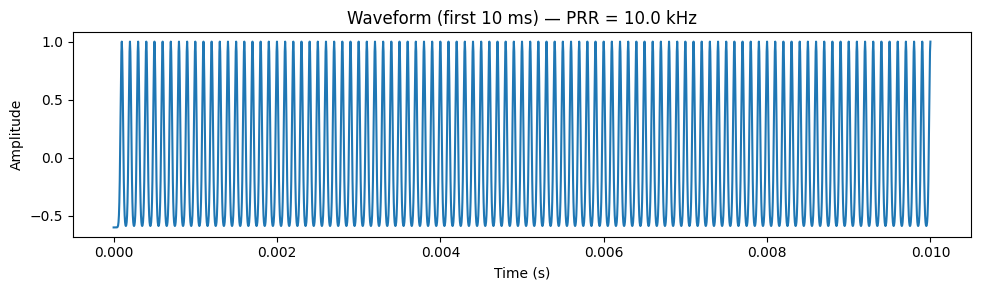

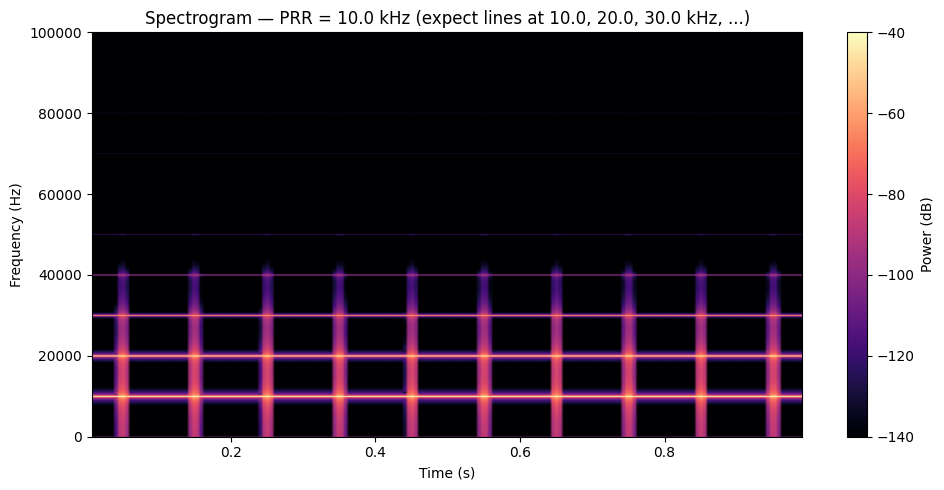

In [116]:


fs = 200_010         # high sample rate to support high PRR
# fs = 200_000          # high sample rate to support high PRR
# fs = 18_000          # high sample rate to support high PRR
duration_s = 1.0
pulse_sigma_s = 15e-6  # ~15 microseconds pulse width (broadband click)

# Try several pulse repetition rates (PRR)
# prrs = [100, 2_000, ]  # Hz
prrs = [10_000, ]  # Hz

audios = []

for prr in prrs:
    t, x = pulse_train(
        fs=fs,
        duration_s=duration_s,
        prr_hz=prr,
        pulse_sigma_s=pulse_sigma_s,
        jitter_std_s=0.0,   # perfectly periodic -> sharp harmonics
        seed=0
    )
    audios.append(x)
    plot_waveform(t, x, title=f"Waveform (first 10 ms) — PRR = {prr/1000:.1f} kHz", tmax=0.01)
    plot_spectrogram(x, fs, title=f"Spectrogram — PRR = {prr/1000:.1f} kHz (expect lines at {prr/1000:.1f}, {2*prr/1000:.1f}, {3*prr/1000:.1f} kHz, ...)",
                        nfft=4096, noverlap=3072, fmax=fs/2)


import IPython.display as ipd

ipd.display(ipd.Audio(audios[0], rate=fs))

/Users/emmanuelfernandez/Documents/orca/orca-calls/.venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


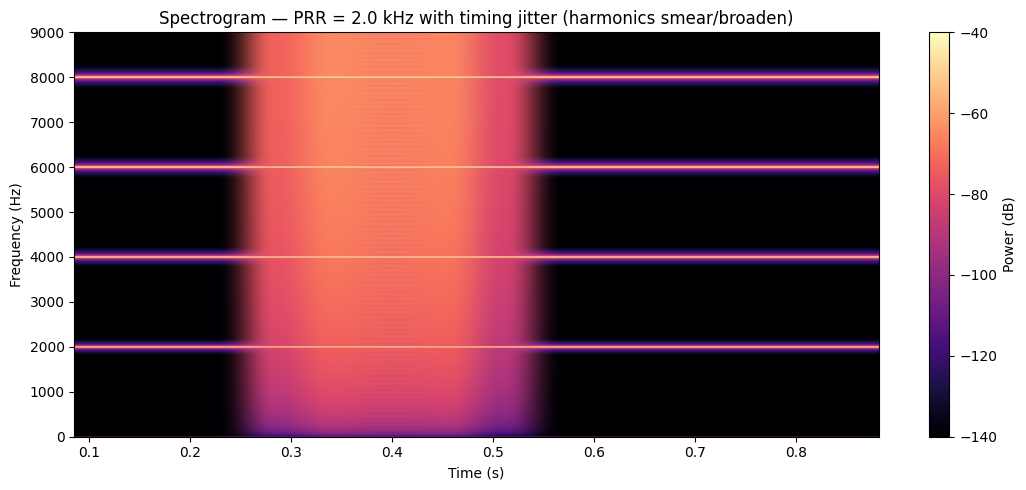

In [48]:

# Show what happens when the timing is NOT perfectly periodic (harmonics smear)
prr = 2000
t, x_jitter = pulse_train(
    fs=fs,
    duration_s=duration_s,
    prr_hz=prr,
    pulse_sigma_s=pulse_sigma_s,
    jitter_std_s=8e-6,  # 2 microseconds jitter -> less periodic
    seed=1
)
plot_spectrogram(
    x_jitter, fs,
    title=f"Spectrogram — PRR = {prr/1000:.1f} kHz with timing jitter (harmonics smear/broaden)",
    nfft=4096, noverlap=3072, fmax=fs/2
)

plt.show()
ipd.display(ipd.Audio(x_jitter, rate=fs))

# Varying PRR

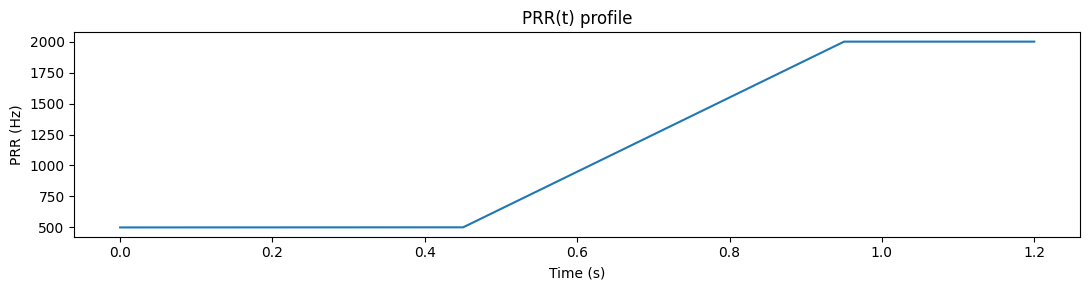

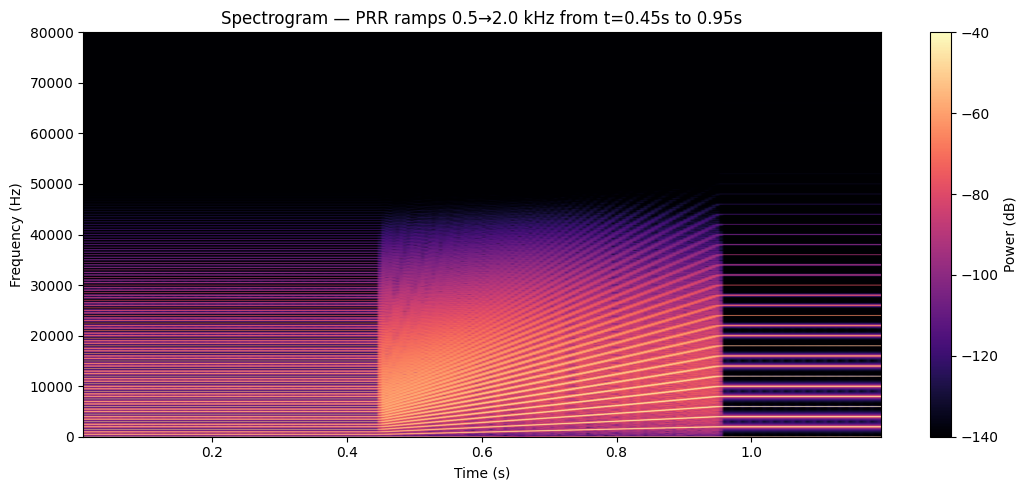

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def prr_profile_linear(t: np.ndarray,
                       prr0_hz: float,
                       prr1_hz: float,
                       t0_s: float,
                       t1_s: float) -> np.ndarray:
    """
    Piecewise PRR(t):
      - prr0 before t0
      - linearly ramps prr0 -> prr1 between t0 and t1
      - prr1 after t1
    """
    prr = np.full_like(t, prr0_hz, dtype=np.float64)
    ramp = (t >= t0_s) & (t <= t1_s)
    after = t > t1_s
    if t1_s > t0_s:
        prr[ramp] = prr0_hz + (prr1_hz - prr0_hz) * (t[ramp] - t0_s) / (t1_s - t0_s)
    prr[after] = prr1_hz
    return prr


def pulse_train_timevarying_prr(fs: int,
                               duration_s: float,
                               prr0_hz: float,
                               prr1_hz: float,
                               t0_s: float,
                               t1_s: float,
                               pulse_sigma_s: float = 15e-6,
                               amp: float = 1.0,
                               jitter_std_s: float = 0.0,
                               seed: int = 0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate a pulse train where PRR changes over time (piecewise linear ramp).
    Pulse times are generated by integrating the instantaneous IPI = 1/PRR(t).

    Returns:
      t: time axis (s)
      x: waveform
      pulse_times: array of pulse center times (s)
    """
    rng = np.random.default_rng(seed)

    n = int(fs * duration_s)
    t = np.arange(n, dtype=np.float64) / fs

    # PRR over time at sample resolution
    prr_t = prr_profile_linear(t, prr0_hz, prr1_hz, t0_s, t1_s)
    prr_t = np.clip(prr_t, 1e-6, None)  # safety

    # Generate pulse center times by stepping forward with IPI(t)=1/PRR(t)
    pulse_times = []
    cur = 0.0
    while cur < duration_s:
        # sample PRR at current time (nearest sample)
        idx = int(min(max(round(cur * fs), 0), n - 1))
        prr_cur = prr_t[idx]
        ipi = 1.0 / prr_cur

        # optional timing jitter (in seconds)
        if jitter_std_s > 0:
            ipi = max(1e-9, ipi + rng.normal(0.0, jitter_std_s))

        pulse_times.append(cur)
        cur += ipi

    pulse_times = np.array(pulse_times, dtype=np.float64)

    # Precompute pulse kernel (Gaussian), spanning ±4 sigma
    half_w = int(np.ceil(4 * pulse_sigma_s * fs))
    k_t = np.arange(-half_w, half_w + 1, dtype=np.float64) / fs
    kernel = np.exp(-0.5 * (k_t / pulse_sigma_s) ** 2)
    kernel = amp * kernel / (np.max(kernel) + 1e-12)

    # Place pulses into waveform
    x = np.zeros(n, dtype=np.float64)
    for c in pulse_times:
        center = int(round(c * fs))
        i0 = center - half_w
        i1 = center + half_w + 1
        if i0 < 0 or i1 > n:
            continue
        x[i0:i1] += kernel

    # Remove DC + normalize
    x -= np.mean(x)
    x /= (np.max(np.abs(x)) + 1e-12)

    return t, x, pulse_times


def plot_spectrogram(x: np.ndarray,
                     fs: int,
                     title: str,
                     nfft: int = 4096,
                     noverlap: int = 3072,
                     fmax: float | None = None,
                     clim_db: tuple[float, float] = (-140, -40)):
    plt.figure(figsize=(11, 5))
    Pxx, freqs, bins, im = plt.specgram(
        x,
        NFFT=nfft,
        Fs=fs,
        noverlap=noverlap,
        scale_by_freq=True,
        sides="default",
        mode="psd",
        cmap="magma"
    )
    im.set_clim(*clim_db)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    if fmax is not None:
        plt.ylim(0, fmax)
    plt.colorbar(im, label="Power (dB)")
    plt.tight_layout()


def plot_prr_over_time(fs: int,
                       duration_s: float,
                       prr0_hz: float,
                       prr1_hz: float,
                       t0_s: float,
                       t1_s: float):
    t = np.arange(int(fs * duration_s), dtype=np.float64) / fs
    prr = prr_profile_linear(t, prr0_hz, prr1_hz, t0_s, t1_s)
    plt.figure(figsize=(11, 3))
    plt.plot(t, prr)
    plt.title("PRR(t) profile")
    plt.xlabel("Time (s)")
    plt.ylabel("PRR (Hz)")
    plt.tight_layout()



fs = 192_000
duration_s = 1.2

# Example: ramp PRR from 6 kHz to 20 kHz between t0=0.45s and t1=0.95s
prr0 = 500
prr1 = 2000
t0 = 0.45
t1 = 0.95

t, x, pulse_times = pulse_train_timevarying_prr(
    fs=fs,
    duration_s=duration_s,
    prr0_hz=prr0,
    prr1_hz=prr1,
    t0_s=t0,
    t1_s=t1,
    pulse_sigma_s=15e-6,
    jitter_std_s=0.0  # set e.g. 2e-6 to smear harmonics a bit
)

plot_prr_over_time(fs, duration_s, prr0, prr1, t0, t1)
plot_spectrogram(
    x, fs,
    title=f"Spectrogram — PRR ramps {prr0/1000:.1f}→{prr1/1000:.1f} kHz from t={t0:.2f}s to {t1:.2f}s",
    nfft=4096,
    noverlap=3072,
    fmax=80_000
)

plt.show()

ipd.display(ipd.Audio(x, rate=fs))


# F0 with librosa


In [70]:
!uv add noisereduce

Resolved 92 packages in 334ms                                        
⠙ Preparing packages... (0/1)                                                   ⠋ Preparing packages... (0/0)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/76.54 KiB           
⠙ Preparing packages... (0/1)------------------- 14.89 KiB/76.54 KiB         
⠙ Preparing packages... (0/1)m------------------ 30.89 KiB/76.54 KiB         
⠙ Preparing packages... (0/1)30m------------ 46.89 KiB/76.54 KiB         
⠙ Preparing packages... (0/1)---------- 62.89 KiB/76.54 KiB         
⠙ Preparing packages... (0/1)---------- 76.54 KiB/76.54 KiB         
Prepared 1 package in 130ms                                                       
Installed 2 packages in 9ms                                 
 + noisereduce==3.0.3
 + tqdm==4.67.3


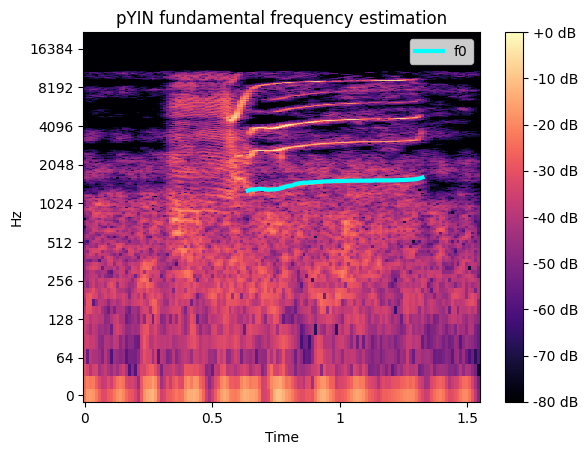

In [108]:
import librosa
import noisereduce as nr
y, sr = librosa.load(librosa.ex('trumpet'))

# y, sr = librosa.load("data/ford-catalogue/Northern Resident/media/R_clan/N32i-R1-2.mp3", sr=None)
y, sr = librosa.load("data/ford-catalogue/Northern Resident/media/A_clan/N09i-A1-1.mp3", sr=None)
y = nr.reduce_noise(y=y, sr=sr)
hop_length = 512  # Use consistent hop length for both pYIN and STFT
f0, voiced_flag, voiced_probs = librosa.pyin(y,
                                             sr=sr,
                                             fmin=100,
                                             fmax=8000,
                                             hop_length=hop_length)
times = librosa.times_like(f0, sr=sr, hop_length=hop_length)

import matplotlib.pyplot as plt
D = librosa.amplitude_to_db(np.abs(librosa.stft(y, hop_length=hop_length)), ref=np.max)
fig, ax = plt.subplots()
img = librosa.display.specshow(D, x_axis='time', y_axis='log', ax=ax, sr=sr, hop_length=hop_length)
ax.set(title='pYIN fundamental frequency estimation')
fig.colorbar(img, ax=ax, format="%+2.f dB")
ax.plot(times, f0, label='f0', color='cyan', linewidth=3)
ax.legend(loc='upper right')

In [99]:
librosa.note_to_hz('C7')

np.float64(2093.004522404789)

In [78]:
ipd.display(ipd.Audio(y, rate=sr))

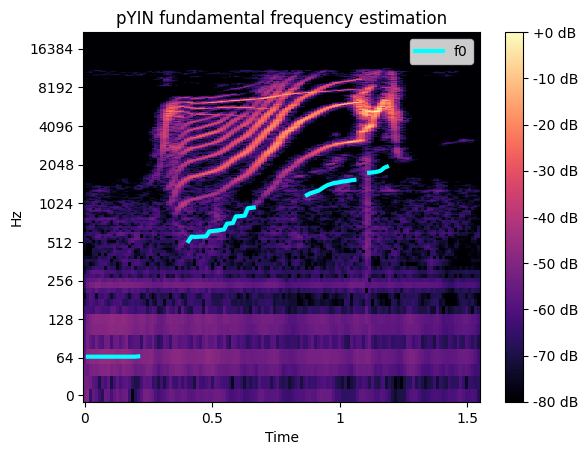